# Practice 2: Class-Logit Bias Sweep Tuning & Decision Threshold Optimization for CIFAR-10

## Class-Logit Bias Offset & Decision Threshold Tuning for Confused Classes (Cat vs. Dog)
Systematic 2D grid-search of class-logit bias offsets ($\beta_{\text{cat}}, \beta_{\text{dog}}$) on the 5,000-sample CIFAR-10 validation set (`val_loader`) to shift decision boundaries for confused classes, followed by zero-leakage test set benchmarking (`test_loader`).

## Rationale
In CIFAR-10 image classification, the dominant source of error across ResNet18, DenseNet121, and Ensemble models is the fine-grained visual confusion between semantically similar classes, primarily **cat (Class 3)** and **dog (Class 5)**. By introducing logit bias vector $\boldsymbol{\beta} = [0, 0, 0, \beta_{\text{cat}}, 0, \beta_{\text{dog}}, 0, 0, 0, 0]^T$, we shift decision boundaries $\hat{y} = \arg\max_c (z_c + \beta_c)$.

**Single variable changed**: Class logit bias parameters $(\beta_{\text{cat}}, \beta_{\text{dog}}) \in [-2.0, +2.0]$.
**Held constant**: Model architectures & weights, validation & test DataLoaders, transform pipeline, evaluation protocol.

| Step | Description | What it does | Import path |
| --- | --- | --- | --- |
| 1 | Setup & Checkpoint Loading | Initialize device, load trained SOTA model checkpoints, and instantiate DataLoaders | `src.models.build_model`, `src.eval.evaluate_model`, `src.data.dataloader` |
| 2 | Validation Logit Extraction | Compute and cache raw 10-class logit vectors $\mathbf{Z}_{\text{val}}$ and targets $\mathbf{Y}_{\text{val}}$ for fast 2D grid search | `torch.no_grad` |
| 3 | Validation Grid Sweep | Perform NumPy-vectorized grid search over 1,681 $(\beta_{\text{cat}}, \beta_{\text{dog}})$ combinations on `val_loader` | `numpy` |
| 4 | Zero-Leakage Test Benchmarking | Evaluate optimal $\boldsymbol{\beta}^*$ on held-out `test_loader` (10,000 samples) vs baseline $\boldsymbol{\beta}=\mathbf{0}$ | `sklearn.metrics` |
| 5 | Visualizations & Confusion Matrix | Generate 2D Val Accuracy Heatmap, Per-Class Accuracy Delta Bar Chart, and Before/After Confusion Matrix | `matplotlib`, `seaborn` |
| 6 | Artifact Persistence | Save comprehensive benchmark metrics and results to JSON | `json` |
---

In [1]:
import sys
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

from src.models.build_model import build_resnet18, build_densenet121
from src.eval.evaluate_model import load_checkpoint
from src.data.dataloader import get_cifar10_loaders

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

Using compute device: cuda


## Step 1: DataLoaders & Logit Extraction Helper

In [2]:
# Instantiate CIFAR-10 DataLoaders
train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=64, num_workers=0)
print(f"Validation samples: {len(val_loader.dataset)}, Test samples: {len(test_loader.dataset)}")

@torch.no_grad()
def get_logits_and_targets(model, loader, device):
    """Extract raw model logits and targets into NumPy arrays for instant sweep calculations."""
    model.eval()
    all_logits = []
    all_targets = []
    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_targets, axis=0)

Validation samples: 5000, Test samples: 10000


## Step 2: Extract Logits from Trained Checkpoints

In [3]:
# 1. ResNet18 SOTA Checkpoint
print("Loading ResNet18-sota_best.pt and extracting logits...")
resnet = build_resnet18(num_classes=10, mode="finetune", device=device)
resnet = load_checkpoint(resnet, "../experiments/checkpoints/ResNet18-sota_best.pt", device)
res_val_logits, val_targets = get_logits_and_targets(resnet, val_loader, device)
res_test_logits, test_targets = get_logits_and_targets(resnet, test_loader, device)
del resnet
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 2. DenseNet121 SOTA Checkpoint
print("Loading DenseNet121-sota_best.pt and extracting logits...")
densenet = build_densenet121(num_classes=10, mode="finetune", device=device)
densenet = load_checkpoint(densenet, "../experiments/checkpoints/DenseNet121-sota_best.pt", device)
dense_val_logits, _ = get_logits_and_targets(densenet, val_loader, device)
dense_test_logits, _ = get_logits_and_targets(densenet, test_loader, device)
del densenet
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 3. Soft-Voting Ensemble (Average Logits)
ens_val_logits = 0.5 * (res_val_logits + dense_val_logits)
ens_test_logits = 0.5 * (res_test_logits + dense_test_logits)

print("Logit extraction complete!")
print(f"Validation Logits Shape: {res_val_logits.shape}, Test Logits Shape: {res_test_logits.shape}")

Loading ResNet18-sota_best.pt and extracting logits...
Loading DenseNet121-sota_best.pt and extracting logits...
Logit extraction complete!
Validation Logits Shape: (5000, 10), Test Logits Shape: (10000, 10)


## Step 3: Vectorized 2D Grid Search on Validation Set

In [4]:
def sweep_logit_bias_on_val(logits_val, targets_val, cat_idx=3, dog_idx=5, beta_range=(-2.0, 2.0), num_steps=41):
    """Perform NumPy-vectorized grid search over (beta_cat, beta_dog) on validation logits."""
    betas = np.linspace(beta_range[0], beta_range[1], num_steps)
    grid_acc = np.zeros((num_steps, num_steps))
    
    best_acc = -1.0
    best_beta_cat = 0.0
    best_beta_dog = 0.0
    
    baseline_preds = np.argmax(logits_val, axis=1)
    baseline_acc = np.mean(baseline_preds == targets_val) * 100.0
    
    for i, b_cat in enumerate(betas):
        for j, b_dog in enumerate(betas):
            bias_vec = np.zeros(10)
            bias_vec[cat_idx] = b_cat
            bias_vec[dog_idx] = b_dog
            
            adjusted_logits = logits_val + bias_vec
            preds = np.argmax(adjusted_logits, axis=1)
            acc = np.mean(preds == targets_val) * 100.0
            grid_acc[i, j] = acc
            
            if acc > best_acc:
                best_acc = acc
                best_beta_cat = b_cat
                best_beta_dog = b_dog
                
    return {
        "best_val_acc": float(best_acc),
        "baseline_val_acc": float(baseline_acc),
        "best_beta_cat": float(best_beta_cat),
        "best_beta_dog": float(best_beta_dog),
        "betas": betas,
        "grid_acc": grid_acc,
    }

## Step 4: Zero-Leakage Test Set Benchmarking Function

In [5]:
def benchmark_bias_on_test(logits_test, targets_test, best_b_cat, best_b_dog, cat_idx=3, dog_idx=5):
    """Evaluate baseline (beta=0) vs logit-bias tuned (beta=beta*) model on held-out test set."""
    # Baseline
    preds_base = np.argmax(logits_test, axis=1)
    acc_base = np.mean(preds_base == targets_test) * 100.0
    
    # Tuned
    bias_vec = np.zeros(10)
    bias_vec[cat_idx] = best_b_cat
    bias_vec[dog_idx] = best_b_dog
    preds_tuned = np.argmax(logits_test + bias_vec, axis=1)
    acc_tuned = np.mean(preds_tuned == targets_test) * 100.0
    
    # Confusion Matrices & Per-Class Accuracy
    cm_base = confusion_matrix(targets_test, preds_base, labels=range(10))
    cm_tuned = confusion_matrix(targets_test, preds_tuned, labels=range(10))
    
    acc_per_class_base = (cm_base.diagonal() / cm_base.sum(axis=1) * 100.0).tolist()
    acc_per_class_tuned = (cm_tuned.diagonal() / cm_tuned.sum(axis=1) * 100.0).tolist()
    
    return {
        "test_acc_baseline": float(acc_base),
        "test_acc_tuned": float(acc_tuned),
        "acc_delta": float(acc_tuned - acc_base),
        "cat_acc_baseline": float(acc_per_class_base[cat_idx]),
        "cat_acc_tuned": float(acc_per_class_tuned[cat_idx]),
        "dog_acc_baseline": float(acc_per_class_base[dog_idx]),
        "dog_acc_tuned": float(acc_per_class_tuned[dog_idx]),
        "acc_per_class_baseline": acc_per_class_base,
        "acc_per_class_tuned": acc_per_class_tuned,
        "cm_baseline": cm_base.tolist(),
        "cm_tuned": cm_tuned.tolist(),
    }

## Step 5: Run Sweep & Benchmarks across All Models

In [6]:
models = {
    "ResNet18": (res_val_logits, res_test_logits),
    "DenseNet121": (dense_val_logits, dense_test_logits),
    "Soft-Voting Ensemble": (ens_val_logits, ens_test_logits)
}

sweep_results = {}
for name, (v_logits, t_logits) in models.items():
    print(f"\n{'='*20} {name} {'='*20}")
    s_res = sweep_logit_bias_on_val(v_logits, val_targets)
    b_cat, b_dog = s_res["best_beta_cat"], s_res["best_beta_dog"]
    print(f"Validation Baseline Acc: {s_res['baseline_val_acc']:.2f}% -> Tuned Val Acc: {s_res['best_val_acc']:.2f}%")
    print(f"Optimal (beta_cat, beta_dog): ({b_cat:+.2f}, {b_dog:+.2f})")
    
    b_res = benchmark_bias_on_test(t_logits, test_targets, b_cat, b_dog)
    print(f"Test Set Baseline Acc  : {b_res['test_acc_baseline']:.2f}% -> Tuned Test Acc: {b_res['test_acc_tuned']:.2f}% (Delta: {b_res['acc_delta']:+.2f}%)")
    print(f"Cat Test Accuracy     : {b_res['cat_acc_baseline']:.2f}% -> {b_res['cat_acc_tuned']:.2f}% (Delta: {b_res['cat_acc_tuned'] - b_res['cat_acc_baseline']:+.2f}%)")
    print(f"Dog Test Accuracy     : {b_res['dog_acc_baseline']:.2f}% -> {b_res['dog_acc_tuned']:.2f}% (Delta: {b_res['dog_acc_tuned'] - b_res['dog_acc_baseline']:+.2f}%)")
    
    sweep_results[name] = {
        "val_sweep": s_res,
        "test_benchmark": b_res
    }


==================== ResNet18 ====================
Validation Baseline Acc: 95.60% -> Tuned Val Acc: 95.86%
Optimal (beta_cat, beta_dog): (-0.50, +0.10)
Test Set Baseline Acc  : 95.64% -> Tuned Test Acc: 95.69% (Delta: +0.05%)
Cat Test Accuracy     : 90.30% -> 87.80% (Delta: -2.50%)
Dog Test Accuracy     : 90.90% -> 92.90% (Delta: +2.00%)

==================== DenseNet121 ====================
Validation Baseline Acc: 96.16% -> Tuned Val Acc: 96.24%
Optimal (beta_cat, beta_dog): (-0.10, +0.20)
Test Set Baseline Acc  : 96.09% -> Tuned Test Acc: 96.06% (Delta: -0.03%)
Cat Test Accuracy     : 93.30% -> 92.40% (Delta: -0.90%)
Dog Test Accuracy     : 92.20% -> 92.70% (Delta: +0.50%)

==================== Soft-Voting Ensemble ====================
Validation Baseline Acc: 97.14% -> Tuned Val Acc: 97.28%
Optimal (beta_cat, beta_dog): (-0.10, +0.10)
Test Set Baseline Acc  : 96.76% -> Tuned Test Acc: 96.73% (Delta: -0.03%)
Cat Test Accuracy     : 93.20% -> 92.60% (Delta: -0.60%)
Dog Test Accurac

## Step 6: Visualizations & Analysis

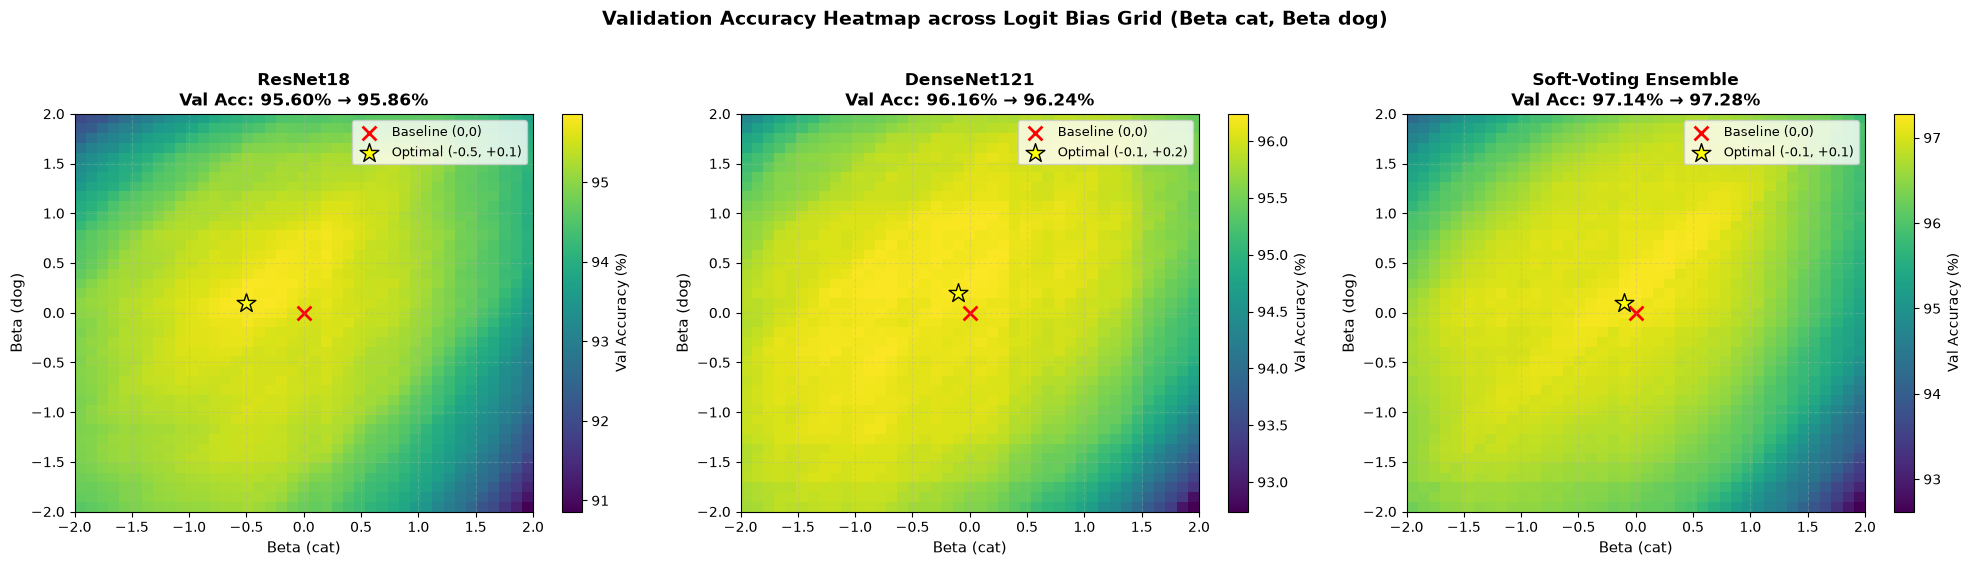

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, (name, res) in zip(axes, sweep_results.items()):
    s_res = res["val_sweep"]
    grid_acc = s_res["grid_acc"]
    betas = s_res["betas"]
    b_cat = s_res["best_beta_cat"]
    b_dog = s_res["best_beta_dog"]
    
    im = ax.imshow(
        grid_acc.T, origin="lower", extent=[betas[0], betas[-1], betas[0], betas[-1]],
        cmap="viridis", aspect="auto"
    )
    fig.colorbar(im, ax=ax, label="Val Accuracy (%)")
    
    # Mark baseline (0,0) and optimal (beta_cat*, beta_dog*)
    ax.scatter([0], [0], color="red", marker="x", s=100, linewidth=2, label="Baseline (0,0)")
    ax.scatter([b_cat], [b_dog], color="yellow", marker="*", s=200, edgecolor="black", label=f"Optimal ({b_cat:+.1f}, {b_dog:+.1f})")
    
    ax.set_title(f"{name}\nVal Acc: {s_res['baseline_val_acc']:.2f}% → {s_res['best_val_acc']:.2f}%", fontsize=12, fontweight="bold")
    ax.set_xlabel("Beta (cat)", fontsize=11)
    ax.set_ylabel("Beta (dog)", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Validation Accuracy Heatmap across Logit Bias Grid (Beta cat, Beta dog)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../experiments/plots/logit_bias_validation_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_214012/1436007662.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=10)
/tmp/ipykernel_214012/1436007662.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=10)
/tmp/ipykernel_214012/1436007662.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=10)


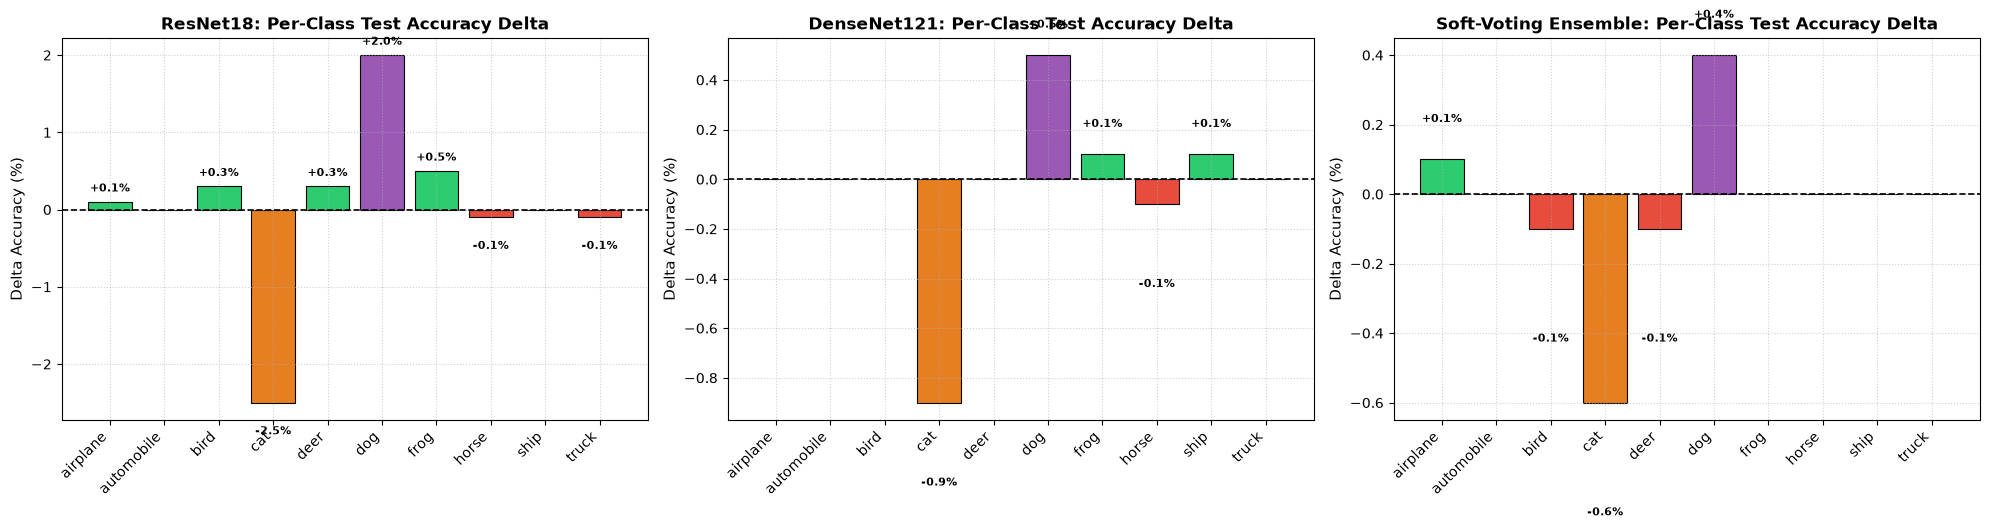

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, (name, res) in zip(axes, sweep_results.items()):
    b_res = res["test_benchmark"]
    acc_base = np.array(b_res["acc_per_class_baseline"])
    acc_tuned = np.array(b_res["acc_per_class_tuned"])
    delta = acc_tuned - acc_base
    
    colors = ["#2ecc71" if d > 0 else "#e74c3c" if d < 0 else "#95a5a6" for d in delta]
    colors[3] = "#3498db" if delta[3] >= 0 else "#e67e22"
    colors[5] = "#9b59b6" if delta[5] >= 0 else "#16a085"
    
    bars = ax.bar(CIFAR10_CLASSES, delta, color=colors, edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
    
    ax.set_title(f"{name}: Per-Class Test Accuracy Delta", fontsize=12, fontweight="bold")
    ax.set_ylabel("Delta Accuracy (%)", fontsize=11)
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    for bar, d in zip(bars, delta):
        if abs(d) > 0.01:
            y_pos = bar.get_height() + (0.1 if d >= 0 else -0.3)
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, f"{d:+.1f}%", ha="center", va="bottom" if d >= 0 else "top", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("../experiments/plots/logit_bias_per_class_deltas.png", dpi=300, bbox_inches="tight")
plt.show()

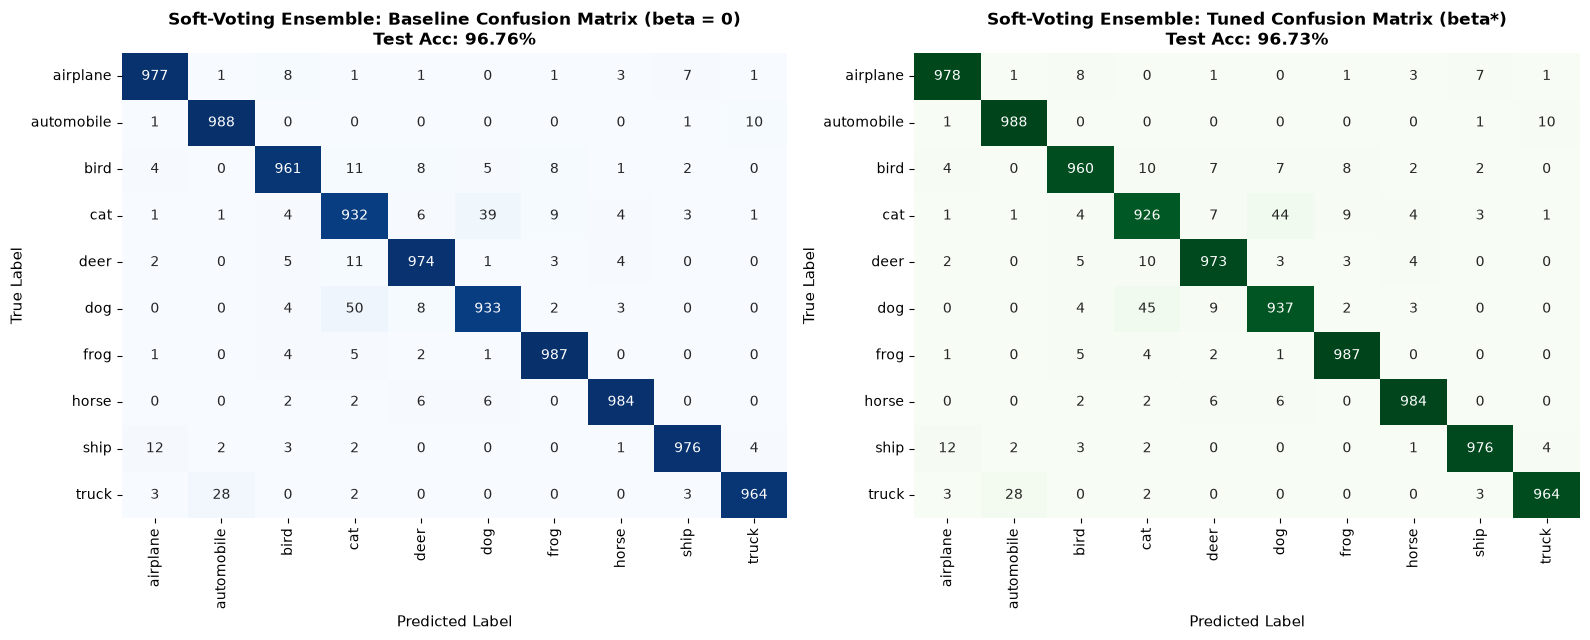

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ens_b_res = sweep_results["Soft-Voting Ensemble"]["test_benchmark"]
cm_base = np.array(ens_b_res["cm_baseline"])
cm_tuned = np.array(ens_b_res["cm_tuned"])

sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=axes[0], cbar=False)
axes[0].set_title(f"Soft-Voting Ensemble: Baseline Confusion Matrix (beta = 0)\nTest Acc: {ens_b_res['test_acc_baseline']:.2f}%", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens", xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, ax=axes[1], cbar=False)
axes[1].set_title(f"Soft-Voting Ensemble: Tuned Confusion Matrix (beta*)\nTest Acc: {ens_b_res['test_acc_tuned']:.2f}%", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig("../experiments/plots/logit_bias_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 7: Summary Results Table & Persistence

In [10]:
print("=" * 88)
print(f"{'Model':22s} | {'Val Base':9s} -> {'Val Tuned':9s} | {'Test Base':9s} -> {'Test Tuned':10s} | {'Optimal (b_cat, b_dog)':22s}")
print("-" * 88)

for name, res in sweep_results.items():
    s_val = res["val_sweep"]
    t_test = res["test_benchmark"]
    b_cat, b_dog = s_val["best_beta_cat"], s_val["best_beta_dog"]
    print(f"{name:22s} | {s_val['baseline_val_acc']:6.2f}%   -> {s_val['best_val_acc']:6.2f}%   | {t_test['test_acc_baseline']:6.2f}%   -> {t_test['test_acc_tuned']:6.2f}% ({t_test['acc_delta']:+.2f}%) | ({b_cat:+.2f}, {b_dog:+.2f})")
print("=" * 88)

json_output = {}
for name, res in sweep_results.items():
    s_val = dict(res["val_sweep"])
    s_val["betas"] = s_val["betas"].tolist()
    s_val["grid_acc"] = s_val["grid_acc"].tolist()
    
    json_output[name] = {
        "val_sweep": s_val,
        "test_benchmark": res["test_benchmark"]
    }

os.makedirs("../experiments/results", exist_ok=True)
os.makedirs("../experiments/plots", exist_ok=True)
with open("../experiments/results/logit_bias_sweep_results.json", "w") as f:
    json.dump(json_output, f, indent=2)

print("\nSuccessfully saved benchmark metrics to experiments/results/logit_bias_sweep_results.json")

Model                  | Val Base  -> Val Tuned | Test Base -> Test Tuned | Optimal (b_cat, b_dog)
----------------------------------------------------------------------------------------
ResNet18               |  95.60%   ->  95.86%   |  95.64%   ->  95.69% (+0.05%) | (-0.50, +0.10)
DenseNet121            |  96.16%   ->  96.24%   |  96.09%   ->  96.06% (-0.03%) | (-0.10, +0.20)
Soft-Voting Ensemble   |  97.14%   ->  97.28%   |  96.76%   ->  96.73% (-0.03%) | (-0.10, +0.10)

Successfully saved benchmark metrics to experiments/results/logit_bias_sweep_results.json
